### DS 3000 Final Project
## Predicting  State of Charge (End %)


---

## Imports

In [26]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

In [5]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DS3000-Final/ev_charging_patterns.csv')
df.head()

Mounted at /content/drive


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler




---

## Pre- Processing

In [6]:
print("========== BASIC SHAPE ==========")
print(df.shape)

print("\n========== TOTAL MISSING VALUES ==========")
print(df.isna().sum().sum())

print("\n========== MISSING VALUES PER COLUMN ==========")
missing_counts = df.isna().sum()
print(missing_counts[missing_counts > 0])

print("\n========== CELLS THAT ARE EMPTY STRINGS ==========")
empty_string_counts = (df == "").sum()
print(empty_string_counts[empty_string_counts > 0])

print("\n========== CELLS THAT ARE WHITESPACE ==========")
whitespace_counts = df.apply(lambda col: col.astype(str).str.strip().eq("").sum())
print(whitespace_counts[whitespace_counts > 0])

print("\n========== SUMMARY ==========")
if (missing_counts.sum() == 0) and (empty_string_counts.sum() == 0) and (whitespace_counts.sum() == 0):
    print("✔ No missing, empty, or whitespace-only cells detected.")
else:
    print("⚠ Missing/empty values detected. Review above.")


========== BASIC SHAPE ==========
(1320, 20)

========== TOTAL MISSING VALUES ==========
198

========== MISSING VALUES PER COLUMN ==========
Energy Consumed (kWh)                       66
Charging Rate (kW)                          66
Distance Driven (since last charge) (km)    66
dtype: int64

========== CELLS THAT ARE EMPTY STRINGS ==========
Series([], dtype: int64)

========== CELLS THAT ARE WHITESPACE ==========
Series([], dtype: int64)

========== SUMMARY ==========
⚠ Missing/empty values detected. Review above.


In [7]:
# Drop rows with missing essential numeric values
df_clean = df.dropna(subset=[
    "Energy Consumed (kWh)",
    "Charging Rate (kW)",
    "Distance Driven (since last charge) (km)"
]).reset_index(drop=True)

print("New shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isna().sum().sum())


New shape: (1131, 20)
Remaining missing values: 0


In [10]:
# Columns to drop
cols_to_drop = [
    "User ID",
    "Charging Station ID",
    "Charging Station Location",
    "Charging Start Time",
    "Charging End Time",
    "Charging Cost (USD)",
    "Time of Day",
    "Day of Week"
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

df_clean.head()


,Vehicle Model,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,BMW i3,108.463007,60.712346,0.591363,36.389181,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,Hyundai Kona,100.000000,12.339275,3.133652,30.677735,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,Chevy Bolt,75.000000,19.128876,2.452653,27.513593,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,Hyundai Kona,50.000000,79.457824,1.266431,32.882870,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,Hyundai Kona,50.000000,19.629104,2.019765,10.215712,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


In [14]:
print("===== CHECKING FOR IMPOSSIBLE VALUES =====\n")

issues = {}

# 1. Battery Capacity
issues["Battery Capacity (kWh) <= 0"] = df_clean[df_clean["Battery Capacity (kWh)"] <= 0]

# 2. Energy Consumed
issues["Energy Consumed (kWh) < 0"] = df_clean[df_clean["Energy Consumed (kWh)"] < 0]
issues["Energy Consumed > Battery Capacity"] = df_clean[
    df_clean["Energy Consumed (kWh)"] > df_clean["Battery Capacity (kWh)"]
]

# 3. Charging Duration
issues["Charging Duration (hours) <= 0"] = df_clean[df_clean["Charging Duration (hours)"] <= 0]
issues["Charging Duration > 24"] = df_clean[df_clean["Charging Duration (hours)"] > 24]

# 4. Charging Rate
issues["Charging Rate (kW) <= 0"] = df_clean[df_clean["Charging Rate (kW)"] <= 0]
issues["Charging Rate > 350 (beyond extreme fast chargers)"] = df_clean[df_clean["Charging Rate (kW)"] > 350]

# 5. Temperature
issues["Temperature below -50 or above 60C"] = df_clean[
    (df_clean["Temperature (°C)"] < -50) | (df_clean["Temperature (°C)"] > 60)
]

# 6. Vehicle Age
issues["Vehicle Age (years) < 0"] = df_clean[df_clean["Vehicle Age (years)"] < 0]
issues["Vehicle Age (years) > 30"] = df_clean[df_clean["Vehicle Age (years)"] > 30]

# 7. State of Charge
issues["Start % outside 0–100"] = df_clean[
    (df_clean["State of Charge (Start %)"] < 0) | (df_clean["State of Charge (Start %)"] > 100)
]
issues["End % outside 0–100"] = df_clean[
    (df_clean["State of Charge (End %)"] < 0) | (df_clean["State of Charge (End %)"] > 100)
]
issues["End % < Start % (charging session should increase SOC)"] = df_clean[
    df_clean["State of Charge (End %)"] < df_clean["State of Charge (Start %)"]
]

# 8. Distance Driven
issues["Distance Driven < 0"] = df_clean[df_clean["Distance Driven (since last charge) (km)"] < 0]


# PRINT SUMMARY
for key, val in issues.items():
    print(f"{key}: {len(val)} rows")

===== CHECKING FOR IMPOSSIBLE VALUES =====

Battery Capacity (kWh) <= 0: 0 rows
Energy Consumed (kWh) < 0: 0 rows
Energy Consumed > Battery Capacity: 170 rows
Charging Duration (hours) <= 0: 0 rows
Charging Duration > 24: 0 rows
Charging Rate (kW) <= 0: 0 rows
Charging Rate > 350 (beyond extreme fast chargers): 0 rows
Temperature below -50 or above 60C: 2 rows
Vehicle Age (years) < 0: 0 rows
Vehicle Age (years) > 30: 0 rows
Start % outside 0–100: 6 rows
End % outside 0–100: 18 rows
End % < Start % (charging session should increase SOC): 238 rows
Distance Driven < 0: 0 rows


In [15]:
print("===== REMOVING IMPOSSIBLE ROWS =====")

# Build a boolean mask of all valid rows
mask = (
    # Energy consumed cannot exceed battery capacity
    (df_clean["Energy Consumed (kWh)"] <= df_clean["Battery Capacity (kWh)"]) &

    # Temperature range must be realistic
    (df_clean["Temperature (°C)"] >= -50) &
    (df_clean["Temperature (°C)"] <= 60) &

    # SOC bounds
    (df_clean["State of Charge (Start %)"] >= 0) &
    (df_clean["State of Charge (Start %)"] <= 100) &
    (df_clean["State of Charge (End %)"] >= 0) &
    (df_clean["State of Charge (End %)"] <= 100) &

    # SOC must increase or stay flat during charging
    (df_clean["State of Charge (End %)"] >= df_clean["State of Charge (Start %)"])
)

# Apply mask
df_clean2 = df_clean[mask].reset_index(drop=True)

print("Original rows:", df_clean.shape[0])
print("Remaining rows after cleaning:", df_clean2.shape[0])
print("Rows removed:", df_clean.shape[0] - df_clean2.shape[0])


===== REMOVING IMPOSSIBLE ROWS =====
Original rows: 1131
Remaining rows after cleaning: 744
Rows removed: 387




---

## Feature Enginnering

In [17]:
df_clean2["SOC_delta (%)"] = (
    df_clean2["State of Charge (End %)"] -
    df_clean2["State of Charge (Start %)"]
)
df_clean2["Energy_per_min (kW)"] = (
    df_clean2["Energy Consumed (kWh)"] /
    (df_clean2["Charging Duration (hours)"] * 60)
)
df_clean2.head()

,Vehicle Model,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type,SOC_delta,Energy_per_min,SOC_delta (%),Energy_per_min (kW)
0,BMW i3,108.463007,60.712346,0.591363,36.389181,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter,56.748386,1.711084,56.748386,1.711084
1,Hyundai Kona,100.000000,12.339275,3.133652,30.677735,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver,74.548566,0.065628,74.548566,0.065628
2,Chevy Bolt,75.000000,19.128876,2.452653,27.513593,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter,63.063011,0.129988,63.063011,0.129988
3,Hyundai Kona,50.000000,19.629104,2.019765,10.215712,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler,9.484836,0.161975,9.484836,0.161975
4,Chevy Bolt,85.000000,36.862140,3.539619,26.185188,60.751781,70.796097,81.338009,27.551335,4.0,Level 2,Commuter,10.044316,0.173569,10.044316,0.173569


In [18]:
print("===== DATA TYPES =====")
print(df_clean2.dtypes)


===== DATA TYPES =====
Vehicle Model                                object
Battery Capacity (kWh)                      float64
Energy Consumed (kWh)                       float64
Charging Duration (hours)                   float64
Charging Rate (kW)                          float64
State of Charge (Start %)                   float64
State of Charge (End %)                     float64
Distance Driven (since last charge) (km)    float64
Temperature (°C)                            float64
Vehicle Age (years)                         float64
Charger Type                                 object
User Type                                    object
SOC_delta                                   float64
Energy_per_min                              float64
SOC_delta (%)                               float64
Energy_per_min (kW)                         float64
dtype: object


In [24]:
# ===== ONE-HOT ENCODING FOR CATEGORICAL COLUMNS =====

categorical_cols = [
    "Vehicle Model",
    "Charger Type",
    "User Type"
]

print("Categorical columns to encode:", categorical_cols)

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_clean2, columns=categorical_cols, drop_first=False)

print("\nNew shape after encoding:", df_encoded.shape)
print("\nPreview of encoded dataframe:")
df_encoded = df_encoded.drop(columns="SOC_delta", errors="ignore")
df_encoded.head()


Categorical columns to encode: ['Vehicle Model', 'Charger Type', 'User Type']

New shape after encoding: (744, 24)

Preview of encoded dataframe:


,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Energy_per_min,...,Vehicle Model_Chevy Bolt,Vehicle Model_Hyundai Kona,Vehicle Model_Nissan Leaf,Vehicle Model_Tesla Model 3,Charger Type_DC Fast Charger,Charger Type_Level 1,Charger Type_Level 2,User Type_Casual Driver,User Type_Commuter,User Type_Long-Distance Traveler
0,108.463007,60.712346,0.591363,36.389181,29.371576,86.119962,293.602111,27.947953,2.0,1.711084,...,False,False,False,False,True,False,False,False,True,False
1,100.000000,12.339275,3.133652,30.677735,10.115778,84.664344,112.112804,14.311026,3.0,0.065628,...,False,True,False,False,False,True,False,True,False,False
2,75.000000,19.128876,2.452653,27.513593,6.854604,69.917615,71.799253,21.002002,2.0,0.129988,...,True,False,False,False,False,False,True,False,True,False
3,50.000000,19.629104,2.019765,10.215712,54.258950,63.743786,203.661847,-7.834199,1.0,0.161975,...,False,True,False,False,False,True,False,False,False,True
4,85.000000,36.862140,3.539619,26.185188,60.751781,70.796097,81.338009,27.551335,4.0,0.173569,...,True,False,False,False,False,False,True,False,True,False




---

## Correlation

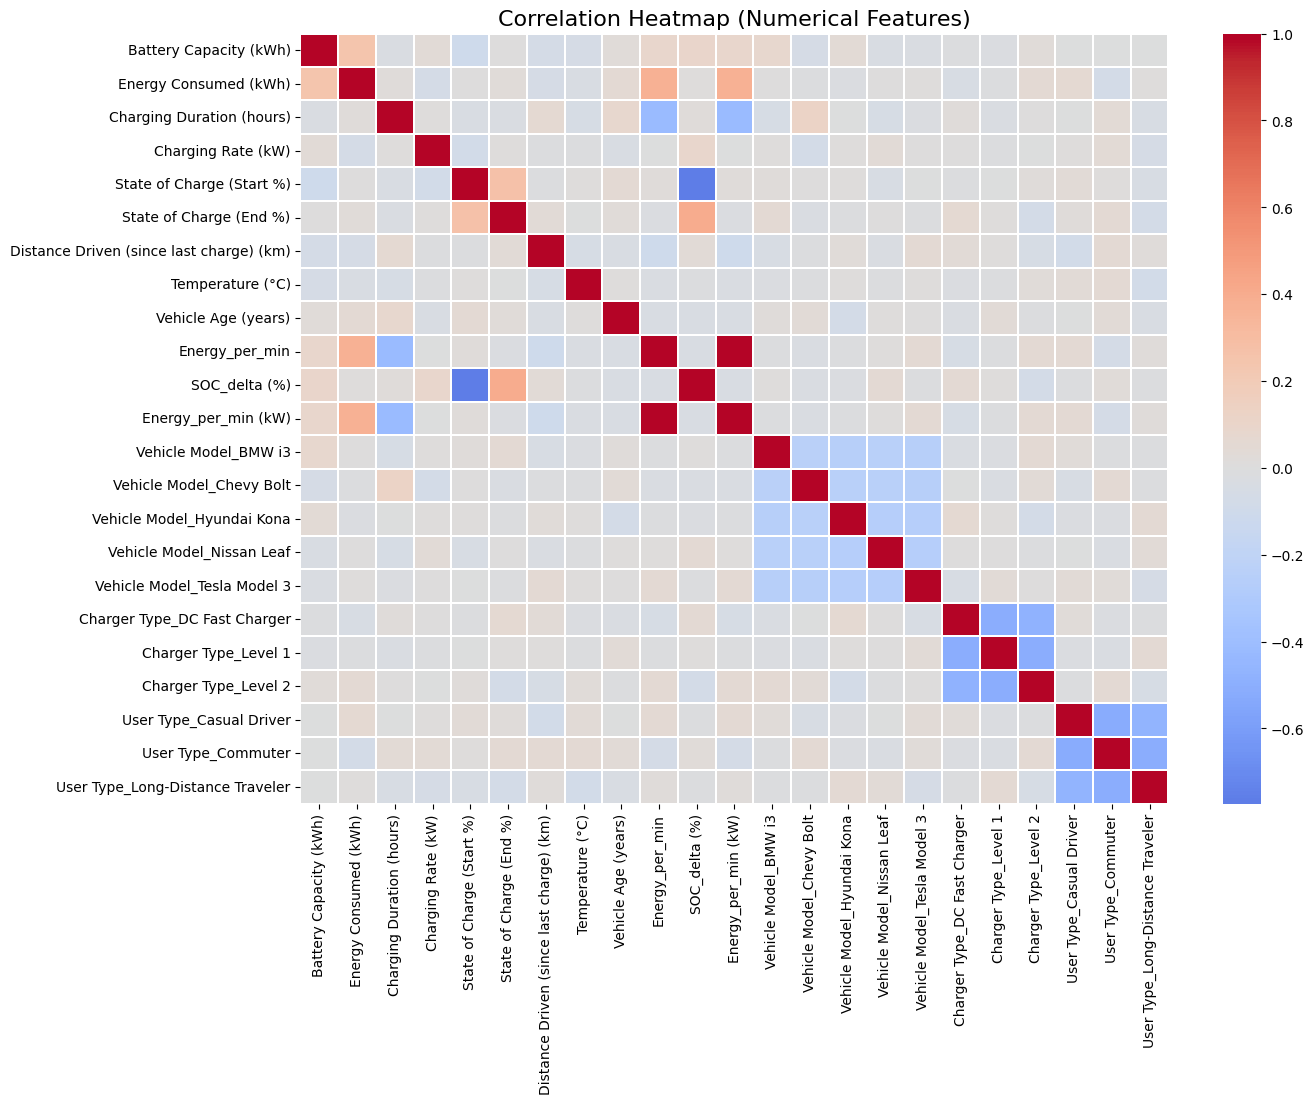


===== TOP CORRELATIONS WITH TARGET =====
State of Charge (End %)                     1.000000
SOC_delta (%)                               0.403394
State of Charge (Start %)                   0.268956
Charger Type_DC Fast Charger                0.063323
User Type_Commuter                          0.054232
Vehicle Model_BMW i3                        0.045315
Distance Driven (since last charge) (km)    0.031042
Energy Consumed (kWh)                       0.029418
Vehicle Age (years)                         0.023583
User Type_Casual Driver                     0.021059
Charging Rate (kW)                          0.013816
Charger Type_Level 1                        0.011480
Vehicle Model_Nissan Leaf                   0.009137
Battery Capacity (kWh)                      0.003354
Temperature (°C)                           -0.002472
Name: State of Charge (End %), dtype: float64


/tmp/ipython-input-2056138948.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


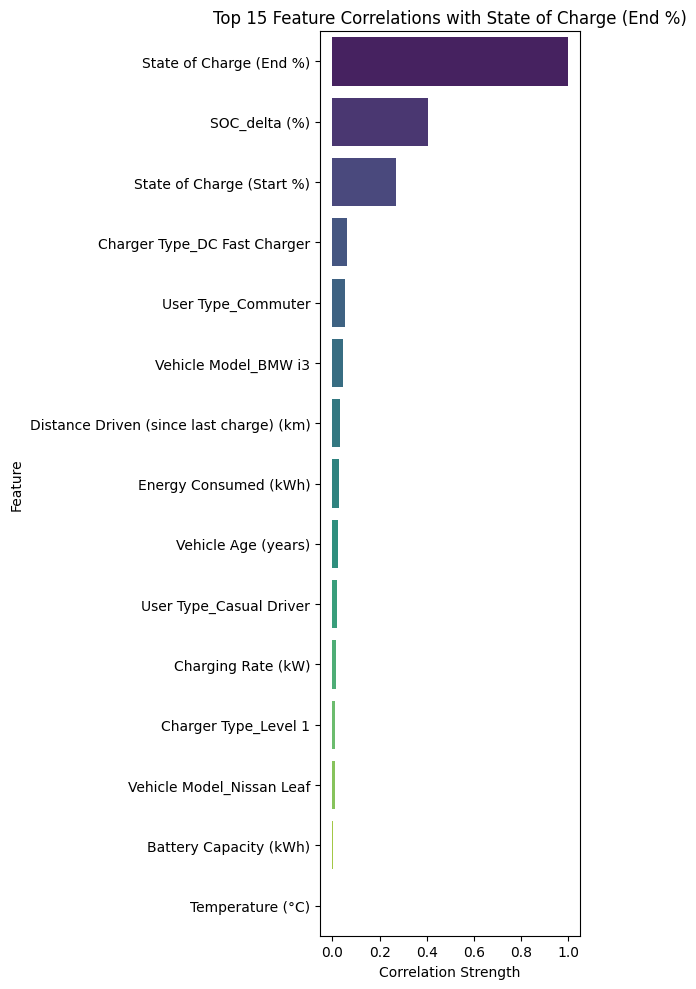

In [25]:
# ---------------------------------------------
# 1. CORRELATION MATRIX (numerical features only)
# ---------------------------------------------
plt.figure(figsize=(14, 10))
corr = df_encoded.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)
plt.title("Correlation Heatmap (Numerical Features)", fontsize=16)
plt.show()

# ---------------------------------------------
# 2. CORRELATION WITH TARGET
# ---------------------------------------------

target = "State of Charge (End %)"   # or "SOC_delta"

corr_target = corr[target].sort_values(ascending=False)
print("\n===== TOP CORRELATIONS WITH TARGET =====")
print(corr_target.head(15))

plt.figure(figsize=(6, 10))
sns.barplot(
    x=corr_target.head(15),
    y=corr_target.head(15).index,
    palette="viridis"
)
plt.title(f"Top 15 Feature Correlations with {target}")
plt.xlabel("Correlation Strength")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [27]:
# ---------------------------------------------
# 3. OPTIONAL: REMOVE LOW-VARIANCE FEATURES
# (categorical one-hot columns sometimes have no variance)
# ---------------------------------------------

selector = VarianceThreshold(threshold=0.0)
selector.fit(df_encoded)

constant_cols = df_encoded.columns[~selector.get_support()]
if len(constant_cols) > 0:
    print("\nRemoving zero-variance columns:", list(constant_cols))
    df_final = df_encoded.drop(columns=constant_cols)
else:
    print("\nNo zero-variance columns found.")


No zero-variance columns found.


In [29]:
# ---------------------------------------------
# 4. EXPORT PROCESSED DATASET
# ---------------------------------------------
output_path = "df_ev_preprocessed.csv"
df_encoded.to_csv(output_path, index=False)

print("\nPreprocessing complete! Saved to:", output_path)
print("Final shape:", df_encoded.shape)



Preprocessing complete! Saved to: df_ev_preprocessed.csv
Final shape: (744, 23)
